In [1]:
%load_ext autoreload
%autoreload 2
%xmode verbose

Exception reporting mode: Verbose


In [4]:
from Exoplanet import Exoplanet
from astroquery.mast import Catalogs

data_paths = []

with open('Exoplanet Discovering/candidate_data_paths.txt', 'r+') as file:
    data_paths.extend([file_name.strip() for file_name in file.readlines()])
    file.seek(0)

for path in data_paths:
    e = Exoplanet.load_from_json(path)

    # data = Catalogs.query_object(f'TIC {e.id_num}', catalog = 'TIC')[0]
    # e.add_host_star_attributes(
    #     radius = data['rad'],
    #     mass = data['mass'],
    #     teff = data['Teff']
    # )

    e.calculate_attributes()

    print(f'{e.id_num}: {e.impact_parameter}')

    e.to_json(f'Exoplanet Discovering/Paper Materials/Data/{e.host_star['name']} Exoplanet {e.letter}.json')

with open('Exoplanet Discovering/candidate_data_paths.txt', 'r+') as file:
    file.truncate(0)

11799872: 0.8246870140515297
23689332: None
35655828: None
35655828: None
38850860: None
55655482: 0.45958223496518685
55727842: 1.0941960771317358
62573638: None
73248090: None
76903841: None
90083037: None
102625324: None
176871438: None
234518605: None
268290940: None
270462117: None
279322914: 0.7129527998624083
284611896: None
295440174: None
297701617: None
300291839: None
306635088: 0.5894151644914982
342556321: None
375477302: None
441444256: None
451596415: None
467113954: None
734505586: None


In [ ]:
import os
import json

data = []

for (dirpath, dirnames, filenames) in os.walk('Exoplanet Discovering/Paper Materials/Data'):
    for filepath in filenames:
        if filepath == '.DS_Store' or filepath.endswith('.csv'):
            continue

        with open(dirpath + '/' + filepath, 'r') as file:
            exoplanet = json.loads(file.read())

        if type(exoplanet) == list:
            continue

        data.append(exoplanet)

    break

data = sorted(data, key = lambda x: x['name'])

with open('Exoplanet Discovering/Paper Materials/Data/full.json', 'w') as file:
    string = json.dumps(data, indent = 4)
    string = string.replace('NaN', 'null')
    string = string.replace('nan', '')

    file.write(string)

In [ ]:
import json

with open('Exoplanet Discovering/Paper Materials/Data/full.json', 'r') as file:
    data = json.loads(file.read())

with open('Exoplanet Discovering/Paper Materials/params_planet_20250503_001.txt', 'w') as file:
    string = ''
    for exoplanet in data:
        string += exoplanet['csv_string'] + '\n'

    file.write(string)

In [ ]:
import json
import pandas
import math

with open('Exoplanet Discovering/Paper Materials/Data/full.json', 'r') as file:
    data = json.loads(file.read())

data = pandas.DataFrame([exoplanet['parameters'] for exoplanet in data])
data['target'] = data['target'].apply(lambda x: x.replace('TIC', 'TIC '))
data = data.set_index('target')
data.replace('', math.nan, inplace = True)
data = data.drop(['tag', 'flag'], axis = 1)
data['disp'] = data['disp'].mask(data['radius'] >= 23.53885947 + 1, 'FP') # z-score radius limit of all candidates/planets, from Nasa Exoplanet Archive
data = data.sort_values(['disp', 'target'
                         ], ascending = [False, True])

data = data.drop(['TIC ' + str(ticid) + '.01' for ticid in [
        284611896,
        268290940,
        62573638,
        23689332,
        441444256,
        234518605,
        306635088,
        451596415,
        375477302]])

columns = ['disp', 'period', 'period_unc', 'epoch', 'epoch_unc', 'r_planet', 'radius', 'mass', 'temp', 'depth', 'depth_unc', 'duration', 'duration_unc', 'sma']
data = data.loc[:, columns]
data['epoch'] -= 2457000
columns = data.select_dtypes(include = 'number').columns.to_list()
for value in ['period', 'depth', 'duration', 'epoch']:
    columns.remove(value)

data[columns] = data[columns].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (3 - 1) - int(math.floor(math.log10(abs(x)))))
)

data[['period', 'depth', 'duration', 'epoch']] = data[['period', 'depth', 'duration', 'epoch']].map(
    lambda x: x if x == 0 or math.isnan(x) else round(x, (6 - 1) - int(math.floor(math.log10(abs(x)))))
)

print(data['mass'].astype(int).to_csv(index = False))
print(data.loc[data['disp'] == 'PC', ['disp', 'mass', 'radius']])

data.replace(math.nan, 'null', inplace = True)

data.index.names = ['Target (CTOI ID)']
data.index = data.index.str.replace('TIC ', '', regex = False)
data['Period (days)'] = data['period'].astype(str) + ' ± ' + data['period_unc'].astype(str)
data['Epoch (BJD_TDB - 2457000)'] = data['epoch'].astype(str) + ' ± ' + data['epoch_unc'].astype(str)
data['Depth (PPM)'] = data['depth'].astype(str) + ' ± ' + data['depth_unc'].astype(str)
data['Duration (hours)'] = data['duration'].astype(str) + ' ± ' + data['duration_unc'].astype(str)
data['Planet Radius / Stellar Radius'] = data['r_planet']

data['Disposition'] = data['disp']
data['Radius (R ⊕)'] = data['radius']
data['Mass (R ⊕)'] = data['mass']
data['Equilibrium Temperature (K)'] = data['temp']
data['Semi-major Axis (AU)'] = data['sma']

data = data[['Period (days)', 'Epoch (BJD_TDB - 2457000)', 'Depth (PPM)', 'Duration (hours)', 'Planet Radius / Stellar Radius',
             'Disposition', 'Radius (R ⊕)', 'Mass (R ⊕)', 'Equilibrium Temperature (K)', 'Semi-major Axis (AU)']]

data.to_csv('Exoplanet Discovering/Paper Materials/Data/ctois.csv')

mass
377
366
491
59
107
454
396
14
41
593
733
611
977
3190
887
3020
1020
1310
6190

                 disp   mass  radius
target                              
TIC 102625324.01   PC  377.0   17.50
TIC 11799872.01    PC  366.0   14.70
TIC 270462117.01   PC  491.0   22.00
TIC 300291839.01   PC   59.5    7.63
TIC 35655828.02    PC  107.0    8.76
TIC 38850860.01    PC  454.0   20.90
TIC 55655482.01    PC  396.0   13.10
TIC 55727842.01    PC   14.5    3.31
TIC 734505586.01   PC   41.0    6.82
TIC 90083037.01    PC  593.0   24.40


In [ ]:
import pandas
import json

with open('Exoplanet Discovering/Paper Materials/Data/full.json', 'r') as file:
    data = json.loads(file.read())

ticids = [exoplanet['id_num'] for exoplanet in data]

data = pandas.DataFrame()
for ticid in ticids:
    url = f'https://exofop.ipac.caltech.edu/tess/download_planet.php?id={ticid}'

    data = pandas.concat([data, pandas.read_csv(url, delimiter = '|')])

data = data.set_index('Name')
data = data.sort_index()
data

In [37]:
from Exoplanet import Exoplanet
import numpy
import lightkurve
import matplotlib.pyplot as plot
from Exoplanet import Exoplanet
import numpy
from astropy.time import Time

e = Exoplanet.load_from_json('Exoplanet Discovering/Paper Materials/Data/TIC 55727842 Exoplanet b.json')

search_result = lightkurve.search_targetpixelfile(e.host_star['name'], mission = 'TESS', cadence = 'long')
pixel_files = search_result.download_all(limit = 20)

collection = lightkurve.LightCurveCollection(None)
for pixel_file in pixel_files[:]:
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux).all(axis = (1, 2))]
    pixel_file = pixel_file[numpy.isfinite(pixel_file.flux_err).all(axis = (1, 2))]

    aperture_mask = pixel_file.pipeline_mask
    # aperture_mask = pixel_file.create_threshold_mask(threshold = 10, reference_pixel = 'center')
    uncorrected_lc = pixel_file.to_lightcurve(aperture_mask = aperture_mask)

    # design_matrix = DesignMatrix(pixel_file.flux[:, ~aperture_mask]).pca(5).append_constant()
    # lc = RegressionCorrector(uncorrected_lc).correct(design_matrix)
    lc = uncorrected_lc
    lc = lc.normalize().flatten(niters = 10).remove_outliers(10.0)
    collection.append(lc)

lc = collection.stitch()

/Users/finny/Documents/Exoplanets/.venv/lib/python3.12/site-packages/astropy/utils/decorators.py:603: LightkurveDeprecationWarning: "t0" was deprecated in version 2.0 and will be removed in a future version. Use argument "epoch_time" instead.
  return function(*args, **kwargs)
/Users/finny/Documents/Exoplanets/.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "utctai" yielded 1 of "dubious year (Note 3)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
/Users/finny/Documents/Exoplanets/.venv/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "taiutc" yielded 1 of "dubious year (Note 4)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


[5.49133309e+00 1.51938777e+03 5.25749110e-02 1.09338786e+01
 6.48937622e-01 4.05290928e-01 2.81572612e-01]


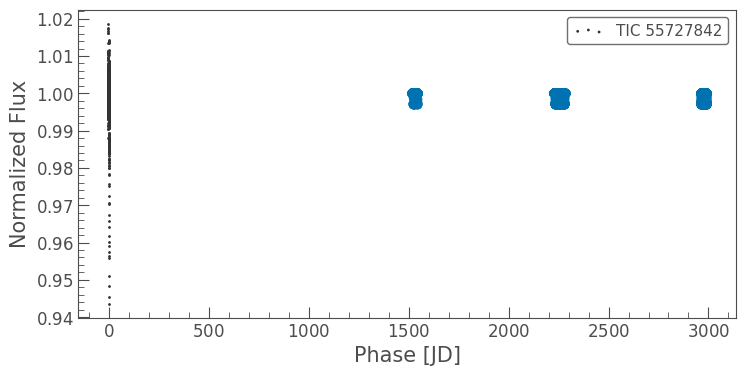

In [38]:
params = e.calculate_using_transit_model(lc)
time = lc.time.value
lc = lc.fold(period = params[0], t0 = Time(params[1], format='jd'))
lc.scatter()
model = Exoplanet.transit_model(params, time)
print(params)
plot.scatter(time, model)
plot.show()